# Classifying MNIST with a quantum kernel

In [1]:
# Necessary imports
import os
import torch
import numpy as np
from tqdm import tqdm
import perceval as pcvl
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
# Helper class
from utils import MNIST_partial

# Quantum Kernel for Photonic Circuits

In the code below, we create the `QuantumKernel` class to handle photonic quantum embeddings for classical data vectors. Specifically, it simulates a photonic circuit, injects photons, and measures the probability distributions of the outputs. The overlap of those probability distributions (fidelity) forms our \emph{quantum kernel} values.

In [2]:
class QuantumKernel:
    """
    Implements a fidelity-based quantum kernel matrix using Perceval,
    where the probability distributions of quantum states are treated as vectors,
    and the kernel values are computed based on their overlap (fidelity).
    
    This kernel can be used for quantum-enhanced machine learning models
    such as Quantum SVM.
    """

    def __init__(self, m: int = 15, n: int = 4):
        """
        Initializes the QuantumKernel instance with the specified number of modes and photons.

        Args:
            m (int): Number of modes in the photonic circuit. Represents the number of channels the photons can travel through.
            n (int): Number of photons used in the quantum circuit. Must be less than `m`.

        Raises:
            ValueError: If `n` is greater than or equal to `m`.
        """
        if n >= m:
            raise ValueError(f"Number of photons n={n} must be less than number of modes m={m}.")
        self.m = m
        self.n = n
        self.processor = pcvl.Processor("SLOS", self.m)
        self.dist_cache = {}  # Cache for precomputed probability distributions
        print(f"[QuantumKernel] Initialized with {self.m} modes, {self.n} photons")

    def _create_circuit(self, features: np.ndarray) -> pcvl.Circuit:
        """
        Creates a photonic circuit based on the input feature vector.

        Args:
            features (np.ndarray): Input feature vector.

        Returns:
            pcvl.Circuit: Configured photonic circuit.

        Steps:
            1. Normalizes the feature values to the [0, 1] range.
            2. Scales the normalized values to phase shifts in the [0, π] range.
            3. Configures the circuit with beam splitters and phase shifts.
        """
        circuit = pcvl.Circuit(self.m)
        
        # Scale normalized features to phase shifts in the range [0, π]
        scaled_features = np.pi * features

        # Step 1: Create entanglement of even pairs using beam splitters
        for k in range(0, self.m - 1, 2):
            circuit.add((k, k + 1), pcvl.BS.Rx())

        # Step 2: Create entanglement of odd pairs using beam splitters
        for k in range(1, self.m - 1, 2):
            circuit.add((k, k + 1), pcvl.BS.Rx())

        # Step 3: Apply feature-dependent phase shifts
        for i in range(min(len(scaled_features), self.m)):
            circuit.add(i, pcvl.PS(scaled_features[i]))

        # Step 4: Create entanglement of even pairs using beam splitters
        for k in range(0, self.m - 1, 2):
            circuit.add((k, k + 1), pcvl.BS.Rx())

        # Step 5: Create entanglement of odd pairs using beam splitters
        for k in range(1, self.m - 1, 2):
            circuit.add((k, k + 1), pcvl.BS.Rx())
            
        return circuit

    def _prob_distribution_for_x(self, x_vec: np.ndarray) -> dict:
        """
        Computes the probability distribution for a given input vector using the photonic circuit.

        Args:
            x_vec (np.ndarray): Input vector representing a data point.

        Returns:
            dict: Probability distribution of measurement outcomes.
        """
        circuit = self._create_circuit(x_vec)
        distribution = np.zeros(self.m, dtype=int)
        for i in range(self.n):
            distribution[i * 2] = 1
        input_state = pcvl.BasicState(distribution)

        self.processor.set_circuit(circuit)
        self.processor.with_input(input_state)
        prob_dict = self.processor.probs()["results"]

        return prob_dict

    def _precompute_distributions(self, X: np.ndarray, desc_label: str) -> list:
        """
        Precomputes the probability distributions for a dataset.

        Args:
            X (np.ndarray): Dataset of input vectors.
            desc_label (str): Description label for progress bar.

        Returns:
            list: List of precomputed probability distributions.
        """
        dist_list = []
        with tqdm(total=len(X), desc=f"Precompute distributions {desc_label}") as pbar:
            for i in range(len(X)):
                x_tuple = tuple(X[i])
                if x_tuple not in self.dist_cache:
                    dist = self._prob_distribution_for_x(X[i])
                    self.dist_cache[x_tuple] = dist
                dist_list.append(self.dist_cache[x_tuple])
                pbar.update(1)
        return dist_list

    def compute_qkernel_block(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        """
        Computes the quantum kernel matrix between two datasets.

        Args:
            X1 (np.ndarray): First dataset.
            X2 (np.ndarray): Second dataset.

        Returns:
            np.ndarray: Quantum kernel matrix.

        Steps:
            1. Precomputes the probability distributions for both datasets.
            2. Computes the fidelity between the distributions to fill the kernel matrix.
            3. Optimizes computation by taking advantage of the symmetry if X1 == X2.
        """
        if not isinstance(X1, np.ndarray):
            X1 = X1.detach().cpu().numpy()
        if not isinstance(X2, np.ndarray):
            X2 = X2.detach().cpu().numpy()

        n1, d1 = X1.shape
        n2, d2 = X2.shape

        print("[INFO] Precomputing output distributions for X1 and X2...")
        dist_list_1 = self._precompute_distributions(X1, desc_label="X1")
        dist_list_2 = dist_list_1 if X1 is X2 else self._precompute_distributions(X2, desc_label="X2")

        K = np.zeros((n1, n2), dtype=float)

        def classical_fidelity(prob_dict_a, prob_dict_b):
            val = 0.0
            for k in prob_dict_a.keys():
                if k in prob_dict_b:
                    val += np.sqrt(prob_dict_a[k] * prob_dict_b[k])
            return val

        print("[INFO] Computing overlaps (kernel matrix)...")
        if X1 is X2:
            with tqdm(total=(n1 * (n1 + 1)) // 2, desc="Compute Symmetric K") as pbar:
                for i in range(n1):
                    K[i, i] = 1.0
                    pbar.update(1)
                    for j in range(i + 1, n2):
                        val = classical_fidelity(dist_list_1[i], dist_list_2[j])
                        K[i, j] = val
                        K[j, i] = val
                        pbar.update(1)
        else:
            with tqdm(total=n1 * n2, desc="Compute QKernel Block") as pbar:
                for i in range(n1):
                    for j in range(n2):
                        K[i, j] = classical_fidelity(dist_list_1[i], dist_list_2[j])
                        pbar.update(1)

        return K

You can see an example of encoding a random vector $x$ of length $m=6$ into a circuit below.

[QuantumKernel] Initialized with 6 modes, 3 photons


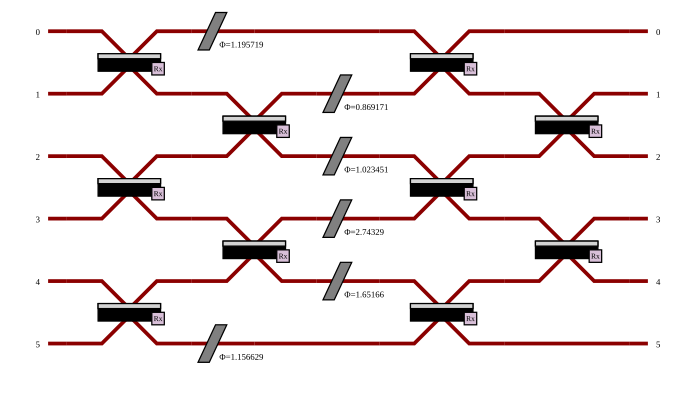

In [3]:
m = 6
q_kernel = QuantumKernel(m, 3)
x = np.random.rand(m)
pcvl.pdisplay(q_kernel._create_circuit(x))

# Quantum SVM Class

Next, we have the `QuantumSVM` class, which uses a `QuantumKernel` instance to generate a kernel matrix. It then trains a Support Vector Machine with this precomputed quantum kernel for multiclass classification. This class provides methods to fit the SVM to training data and predict labels on new test data.

In [4]:
class QuantumSVM:
    """
    A quantum-enhanced SVM model for multiclass classification,
    using scikit-learn's SVC with a 'precomputed' quantum kernel.
    
    This class leverages a QuantumKernel instance to compute quantum kernel matrices, 
    which are then used as input to a support vector classifier (SVC) from scikit-learn.
    """

    def __init__(self, m=10, n=2, svc_args={"C": 10.0, "decision_function_shape": "ovr"}, dir_save="qkernel"):
        """
        Initializes the QuantumSVM class with the specified hyperparameters.

        Args:
            C (float): Regularization parameter for the SVM. A higher value indicates stronger regularization.
            m (int): Number of modes in the photonic circuit. 
            n (int): Number of photons used in the quantum circuit. Must be less than `m`.
            dir_save (str): Directory where quantum kernel matrices will be saved.
        """
        self.m = m
        self.n = n
        self.svc_args = svc_args
        self.dir_save = dir_save

        self.svc_ = None  # SVM model instance
        self.X_train_ = None  # Training data
        self.kernel_train_ = None  # Quantum kernel matrix for training data

        # Instantiate our quantum kernel simulator
        self.qkernel_ = QuantumKernel(m=self.m, n=self.n)

    def fit(self, X_train, y_train, kernel_type="standard", kernel_args=None):
        """
        Fits the QuantumSVM model to the training data.

        This method computes the quantum kernel matrix for the training set and uses it to fit
        an SVM classifier with a precomputed kernel.

        Args:
            X_train (array-like): Training data features.
            y_train (array-like): Training data labels.

        Steps:
            1. Computes the quantum kernel matrix for the training data (K_train).
            2. Saves the kernel matrix to the specified directory.
            3. Fits an SVM model using the precomputed kernel matrix.
        """
        print("[INFO] Computing quantum kernel matrix on training set...")
        self.X_train_ = X_train

        # Compute K_train of shape (N_train, N_train)
        K_train = self.qkernel_.compute_qkernel_block(X_train, X_train)

        # Create the directory if it doesn't exist
        os.makedirs(self.dir_save, exist_ok=True)

        # Save the kernel matrix to a file with a parameter-based filename
        filename = f"{self.dir_save}/quantum_kernel_train_m{self.m}_n{self.n}.npy"
        np.save(filename, K_train)
        print(f"[INFO] Saved quantum kernel matrix to '{filename}'.")

        # Transform the kernel if needed
        if kernel_type == "poly":
            gamma = kernel_args["gamma"]
            coef = kernel_args["coef"]
            degree = kernel_args["degree"]
            K_train = (gamma * K_train + coef) ** degree
        elif kernel_type == "sigmoid":
            alpha = kernel_args["alpha"]
            coef = kernel_args["coef"]
            K_train = np.tanh(alpha * K_train + coef)

        self.kernel_train_ = K_train

        # Initialize and fit the SVM classifier
        self.svc_ = SVC(kernel="precomputed", **self.svc_args)
        self.svc_.fit(self.kernel_train_, y_train)
        print("[INFO] QuantumSVM training complete.")

    def predict(self, X_test, kernel_type="standard", kernel_args=None):
        """
        Predicts the labels for the test data using the fitted QuantumSVM model.

        This method computes the quantum kernel matrix block for the test set and
        uses the fitted SVM model to make predictions.

        Args:
            X_test (array-like): Test data features.

        Returns:
            array-like: Predicted labels for the test data.

        Steps:
            1. Computes the quantum kernel block matrix (K_test).
            2. Uses the precomputed kernel to make predictions with the fitted SVM model.
            3. Saves the test kernel matrix to the specified directory.
        """
        if self.svc_ is None:
            raise RuntimeError("Must call fit() first.")

        print("[INFO] Computing quantum kernel matrix on test set...")
        K_test = self.qkernel_.compute_qkernel_block(X_test, self.X_train_)

        # Save the test kernel matrix
        filename = f"{self.dir_save}/quantum_kernel_test_m{self.m}_n{self.n}.npy"
        np.save(filename, K_test)

        # Transform the kernel if needed
        if kernel_type == "poly":
            gamma = kernel_args["gamma"]
            coef = kernel_args["coef"]
            degree = kernel_args["degree"]
            K_test = (gamma * K_test + coef) ** degree
        elif kernel_type == "sigmoid":
            alpha = kernel_args["alpha"]
            coef = kernel_args["coef"]
            K_test = np.tanh(alpha * K_test + coef)

        preds = self.svc_.predict(K_test)
        return preds


# Run the Training

Finally, we provide a helper function `run_training` that orchestrates the entire pipeline:
1. Load a partial MNIST dataset (train and validation).
2. Apply PCA for dimensionality reduction.
3. Scale the features to [0,1].
4. Initialize the `QuantumSVM` model with chosen hyperparameters.
5. Fit the model on the training set.
6. Evaluate predictions on the validation set.
7. Print out various metrics.

After defining `run_training`, we call it with specific parameter choices for number of modes/photons and a sigmoid kernel to demonstrate how to run the entire pipeline from start to finish.

In [5]:
def run_training(
    data_path="./data",
    random_seed=42,
    n_components=10,
    m_modes=10,
    n_photons=2,
    svc_args={"C": 10.0, "decision_function_shape": "ovr"},
    kernel_type="standard",
    kernel_args=None,
    dir_save="qkernel"
):
    """
    Trains a quantum support vector machine (QuantumSVM) model using the MNIST dataset.

    Args:
        data_path (str): Path to the directory containing the MNIST dataset.
        C (float): Regularization parameter for the SVM. Larger values specify stronger regularization.
        random_seed (int): Random seed for reproducibility.
        n_components (int): Number of principal components to retain after applying PCA.
        m_modes (int): Number of modes (quantum states) in the quantum circuit.
        n_photons (int): Number of photons used in the quantum circuit.
        dir_save (str): Directory name where quantum kernel data will be saved.

    Returns:
        None. The function prints evaluation metrics including validation accuracy, classification report, and confusion matrix.

    Steps:
        1. Loads the MNIST dataset (partial train and validation splits).
        2. Reshapes and prepares the dataset for processing.
        3. Applies PCA to reduce dimensionality of the dataset to `n_components` features.
        4. Normalizes the PCA-transformed data to a range of [0, 1] using `MinMaxScaler`.
        5. Initializes a QuantumSVM model with the specified parameters.
        6. Trains the QuantumSVM model using the training set.
        7. Predicts on the validation set and evaluates the model using accuracy score, classification report, and confusion matrix.
    """
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    # 1) Load dataset
    train_dataset = MNIST_partial(data=data_path, split="train")
    val_dataset = MNIST_partial(data=data_path, split="val")

    # We load them fully (just once)
    train_loader = DataLoader(train_dataset, batch_size=len(train_dataset))
    val_loader = DataLoader(val_dataset, batch_size=len(val_dataset))

    # 2) Process data
    for images, labels in train_loader:
        X_train_full = images.reshape(len(train_dataset), -1).numpy()  # shape [N, 784]
        y_train_full = labels.numpy()

    for images, labels in val_loader:
        X_val_full = images.reshape(len(val_dataset), -1).numpy()      # shape [N, 784]
        y_val_full = labels.numpy()

    X_train_full = X_train_full[:600]
    y_train_full = y_train_full[:600]
    X_val_full = X_val_full[:60]
    y_val_full = y_val_full[:60]
    print(f"[INFO] Original shapes: Train={X_train_full.shape}, Val={X_val_full.shape}")

    # 3) PCA -> n_components components
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_full)
    X_val_pca   = pca.transform(X_val_full)
    print(f"[INFO] After PCA: Train shape={X_train_pca.shape}, Val shape={X_val_pca.shape}")

    # Normalize PCA outputs to [0,1] range
    scaler = MinMaxScaler(feature_range=(0,1))
    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_val_scaled = scaler.transform(X_val_pca)

    # 4) Build Quantum SVM
    qsvm = QuantumSVM(
        m=m_modes,
        n=n_photons,
        svc_args=svc_args,
        dir_save=dir_save
    )

    # 5) Fit (this will compute the NxN kernel once)
    print("[INFO] Fitting Quantum SVM on training set...")
    qsvm.fit(X_train_scaled, y_train_full, kernel_type, kernel_args)

    # 6) Predict on the test set
    print("[INFO] Predicting on validation set...")
    val_preds = qsvm.predict(X_val_scaled, kernel_type, kernel_args)

    # 7) Evaluate
    acc = accuracy_score(y_val_full, val_preds)
    print(f"[RESULT] Validation Accuracy = {acc:.4f}")
    print("Classification Report:\n", classification_report(y_val_full, val_preds))
    print("Confusion Matrix:\n", confusion_matrix(y_val_full, val_preds))

In [6]:
m_modes = 20
n_photons = 5
folder_path = "qkernel_results"

run_training(
    data_path="./data",
    random_seed=42,
    n_components=m_modes, 
    m_modes=m_modes,       
    n_photons=n_photons,
    svc_args={'C': 25.0, 'decision_function_shape': "ovr", 'tol': 0.001},
    kernel_type="sigmoid",
    kernel_args={'alpha': 1.0, 'coef': -1.0},
    dir_save=folder_path   
)

[INFO] Original shapes: Train=(600, 784), Val=(60, 784)
[INFO] After PCA: Train shape=(600, 20), Val shape=(60, 20)
[QuantumKernel] Initialized with 20 modes, 5 photons
[INFO] Fitting Quantum SVM on training set...
[INFO] Computing quantum kernel matrix on training set...
[INFO] Precomputing output distributions for X1 and X2...


Precompute distributions X1: 100%|██████████| 600/600 [00:20<00:00, 29.73it/s]


[INFO] Computing overlaps (kernel matrix)...


Compute Symmetric K: 100%|██████████| 180300/180300 [11:54<00:00, 252.22it/s]


[INFO] Saved quantum kernel matrix to 'qkernel_results/quantum_kernel_train_m20_n5.npy'.
[INFO] QuantumSVM training complete.
[INFO] Predicting on validation set...
[INFO] Computing quantum kernel matrix on test set...
[INFO] Precomputing output distributions for X1 and X2...


Precompute distributions X2: 100%|██████████| 600/600 [00:00<00:00, 475454.83it/s]


[INFO] Computing overlaps (kernel matrix)...


Compute QKernel Block: 100%|██████████| 36000/36000 [02:25<00:00, 247.99it/s]

[RESULT] Validation Accuracy = 0.8167
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00         8
           2       0.83      0.83      0.83        12
           3       1.00      0.83      0.91         6
           4       0.57      1.00      0.73         4
           5       0.67      1.00      0.80         4
           6       0.50      1.00      0.67         3
           7       0.88      0.88      0.88         8
           8       1.00      0.33      0.50         6
           9       1.00      0.33      0.50         3

    accuracy                           0.82        60
   macro avg       0.84      0.80      0.77        60
weighted avg       0.87      0.82      0.81        60

Confusion Matrix:
 [[ 5  0  0  0  0  0  1  0  0  0]
 [ 0  8  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  1  0  1  0  0]
 [ 0  0  0  5  0  0  1  0  0  0]
 [ 0  0  0  0  4  0  0  0  0

# Comparison to classical
For comparison, we implement classical SVM for the same train and test datasets with the same number of components in PCA. We observe similar performance.

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import torch
import numpy as np
from torch.utils.data import DataLoader
from utils import MNIST_partial

# Set random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 1) Load dataset
data_path = "./data"
train_dataset = MNIST_partial(data=data_path, split="train")
val_dataset = MNIST_partial(data=data_path, split="val")

# Load data fully (just once)
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset))
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset))

for images, labels in train_loader:
    X_train = images.reshape(len(train_dataset), -1).numpy()
    y_train = labels.numpy()

for images, labels in val_loader:
    X_val = images.reshape(len(val_dataset), -1).numpy()
    y_val = labels.numpy()

# 2) Optionally limit the dataset size for speed
max_train = 600
max_val = 60
X_train = X_train[:max_train]
y_train = y_train[:max_train]
X_val = X_val[:max_val]
y_val = y_val[:max_val]

# 3) PCA -> n_components components
n_components = 20
pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_val = pca.transform(X_val)
print(f"[INFO] After PCA: Train shape={X_train.shape}, Val shape={X_val.shape}")

# Normalize PCA outputs to [0,1] range
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1.0, 5.0, 10.0, 15.0, 100.0],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],  # Only relevant for 'poly' kernel
    # 'kernel': ['linear', 'poly', 'sigmoid']
}

# Initialize SVM model
svc = SVC(random_state=random_seed)

# Perform grid search for all kernels
grid_search = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters for each kernel type
kernels = ['linear', 'sigmoid', 'poly']
for kernel in kernels:
    print(f"\nPerforming Grid Search for {kernel} Kernel...")
    
    # Define a kernel-specific parameter grid
    param_grid_kernel = {
        'C': [0.1, 1.0, 10.0, 25.0, 100.0],
        'gamma': ['scale', 'auto'],
        'degree': [3, 4, 5] if kernel == 'poly' else None,
        'kernel': [kernel]
    }
    
    # Remove None values from the parameter grid
    param_grid_kernel = {k: v for k, v in param_grid_kernel.items() if v is not None}

    # Perform Grid Search for the specific kernel
    grid_search = GridSearchCV(SVC(random_state=random_seed), param_grid_kernel, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    # Get the best model for this kernel
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_val_scaled)
    
    # Print best result for this kernel
    print(f"\nBest Results for {kernel} Kernel:")
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_val, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))


[INFO] After PCA: Train shape=(600, 20), Val shape=(60, 20)

Performing Grid Search for linear Kernel...

Best Results for linear Kernel:
Validation Accuracy: 0.9000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.80      1.00      0.89         8
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00         6
           4       0.67      1.00      0.80         4
           5       0.67      1.00      0.80         4
           6       1.00      1.00      1.00         3
           7       1.00      0.88      0.93         8
           8       1.00      0.67      0.80         6
           9       1.00      0.33      0.50         3

    accuracy                           0.90        60
   macro avg       0.91      0.88      0.87        60
weighted avg       0.93      0.90      0.90        60

Confusion Matrix:
 [[ 6  0  0  0  0  0  0  0  0  0]